<a href="https://colab.research.google.com/github/joebathelt/AUC_Neuroimaging/blob/main/MindReading_Week7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install nilearn

# Design Matices and First-level Analysis
Two weeks ago, we learned that we can model the BOLD signal using the haemodynamic response function (HRF) and a design matrix. The design matrix is a mathematical representation of the experimental conditions and their timing. It allows us to estimate the contribution of each condition to the observed BOLD signal. In Week 5, we used matrix algebra to fit the HRF to the BOLD signal and estimate the parameters of the model. In practice, we do not implement the matrix algebra ourselves, but instead use software packages that perform these calculations for us. In this section, we will learn how to create design matrices and perform first-level analysis using nilearn.

In this notebook, you will learn how to set up and run a **first-level GLM analysis** of fMRI data using [**Nilearn**](https://nilearn.github.io/).
A first-level analysis refers to the statistical modelling of a **single participant’s** data, and it forms the foundation for all subsequent group-level analyses.

**Expected time to complete**: ~90 minutes


## Setup

Run the cell below to load the packages we will use throughout this notebook.

In [ ]:
# Loading required packages
import matplotlib.pyplot as plt
from nilearn import datasets, image, plotting
from nilearn.glm.first_level import FirstLevelModel, make_first_level_design_matrix
from nilearn.plotting import plot_design_matrix
import numpy as np
import pandas as pd
import os
import urllib.request

### The dataset

For this analysis, we use real fMRI data from the **NI-edu dataset**, which was collected at the 3T scanner at the University of Amsterdam. The dataset was specifically designed for teaching neuroimaging analysis.

We will work with data from a **functional localiser** task (abbreviated *flocBLOCKED*).  
During this task, participants viewed images from five categories — **faces, bodies, characters, objects, and places** — presented in blocks.
Each block lasted approximately 6 seconds, with short baseline periods between blocks.
The participant performed a simple **one-back task**, pressing a button whenever the same image appeared twice in a row.

This blocked design produces robust signals that are well-suited for illustrating how the GLM works in practice.

### Downloading the data

The cell below downloads the preprocessed files we need for the analysis:

- The **preprocessed BOLD image** (functional data in MNI space)  
- The **brain mask** (defines which voxels to include in the analysis)  
- The **events file** (records when each stimulus category was presented)  
- The **confounds file** (nuisance regressors estimated during preprocessing)  
- An additional **events file** from an auditory oddball experiment (used in the exercises)

In [ ]:
def download_file(url, outfile):
    """Download file from URL if not already present."""
    if not os.path.exists(outfile):
        print(f"Downloading {outfile}...")
        urllib.request.urlretrieve(url, outfile)
        print(f"Saved as {outfile}")
    else:
        print(f"{outfile} already exists, skipping download.")

download_file(
    "https://www.dropbox.com/scl/fi/lzn45xzix3impqy8je652/sub-03_ses-1_task-flocBLOCKED_desc-confounds_timeseries.tsv?rlkey=n1ee5hl7x3gb6balvv0ogrkaa&dl=1",
    "sub-03_ses-1_task-flocBLOCKED_desc-confounds_timeseries.tsv"
)

download_file(
    "https://www.dropbox.com/scl/fi/6dmmh7yrf2vla7c1ydnmk/sub-03_ses-1_task-flocBLOCKED_space-MNI152NLin2009cAsym_desc-brain_mask.nii.gz?rlkey=ikkmhl6ru65j3ddtq2ajpx8tz&dl=1",
    "sub-03_ses-1_task-flocBLOCKED_space-MNI152NLin2009cAsym_desc-brain_mask.nii.gz"
)

download_file(
    "https://www.dropbox.com/scl/fi/2ruyaxfamq383smeojlp4/sub-03_ses-1_task-flocBLOCKED_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz?rlkey=2kdevsmm8jbnxgruxrgxhv6y9&dl=1",
    "sub-03_ses-1_task-flocBLOCKED_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz"
)

download_file(
    "https://www.dropbox.com/scl/fi/lpyjivgsf2c7ejasvoze9/sub-03_ses-1_task-flocBLOCKED_events.tsv?rlkey=uyi5gsiyzishysgpsxe8w2yr9&dl=1",
    "sub-03_ses-1_task-flocBLOCKED_events.tsv"
)

download_file(
    "https://www.dropbox.com/scl/fi/vvb4pkjfszd9gcfii8tiz/sub-01_task-auditoryoddball_events.tsv?rlkey=aa9qzxiz3211cb10bnedfsp4n&dl=1",
    "sub-01_task-auditoryoddball_events.tsv"
)

sub-03_ses-1_task-flocBLOCKED_desc-confounds_timeseries.tsv already exists, skipping download.
sub-03_ses-1_task-flocBLOCKED_space-MNI152NLin2009cAsym_desc-brain_mask.nii.gz already exists, skipping download.
sub-03_ses-1_task-flocBLOCKED_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz already exists, skipping download.
sub-03_ses-1_task-flocBLOCKED_events.tsv already exists, skipping download.
sub-01_task-auditoryoddball_events.tsv already exists, skipping download.


## Step 1: Loading the experimental events

The first ingredient for a GLM analysis is the **events file**.  
This file records what happened during the experiment: specifically, the **onset** (when each event started), the **duration** (how long it lasted), and the **trial type** (which condition it belongs to).

These three columns are the minimum that Nilearn requires to build a design matrix.

In [ ]:
events_df = pd.read_csv('./sub-03_ses-1_task-flocBLOCKED_events.tsv', sep='\t')
events = events_df[['onset', 'duration', 'trial_type']]

print(f"Number of events: {len(events)}")
print(f"Conditions: {events['trial_type'].unique()}")
print()
print(events.head(10))

Number of events: 378
Conditions: ['object' 'response' 'character' 'body' 'face' 'place']

       onset  duration trial_type
0   6.028594  0.374968     object
1   6.520242  0.383304     object
2   7.020227  0.383306     object
3   7.520218  0.383302     object
4   7.645309  0.100000   response
5   8.020202  0.383303     object
6   8.520181  0.383309     object
7   9.020167  0.383310     object
8   9.520166  0.383298     object
9  10.020156  0.383294     object


The events file tells us that this experiment included five stimulus categories: **body, character, face, object,** and **place**.  
Each event has an onset time (in seconds from the start of the scan) and a duration.  
In a blocked design like this one, events within the same block share the same trial type.

## Step 2: Loading the confound regressors

The second ingredient is the **confounds file**, which contains nuisance variables — that is, sources of signal variation that are not related to the experimental task.  
Including these in the model helps to reduce noise and improve the sensitivity of the analysis.

Here, we include:
- The **six motion parameters** (translations and rotations in x, y, z), which capture head movement during scanning  
- The **global signal**, which reflects whole-brain fluctuations  
- The signals from **white matter** and **cerebrospinal fluid (CSF)**, which are not expected to contain task-related neural signal  
- The **first derivatives** of all of the above, which capture sudden changes over time

In [ ]:
confounds_df = pd.read_csv(
    './sub-03_ses-1_task-flocBLOCKED_desc-confounds_timeseries.tsv', sep='\t'
)

# Define the base confound variables
confound_vars = [
    'global_signal', 'csf', 'white_matter',
    'rot_x', 'rot_y', 'rot_z',
    'trans_x', 'trans_y', 'trans_z'
]

# Also include the first derivatives (capture sudden changes)
confound_vars += [f'{var}_derivative1' for var in confound_vars]

# Select columns and replace any missing values with 0
confounds = confounds_df[confound_vars].fillna(0)

print(f'Confounds matrix shape: {confounds.shape}')
print(f'(That is {confounds.shape[0]} time points and {confounds.shape[1]} nuisance regressors)')

Confounds matrix shape: (325, 18)
(That is 325 time points and 18 nuisance regressors)


## Step 3: Setting up and fitting the first-level model

With the events and confounds in hand, we can now define and fit the **first-level GLM**.

The key settings are:
- **`t_r`**: the repetition time (TR), which is 0.7 seconds for this dataset  
- **`hrf_model`**: the shape of the haemodynamic response function (HRF) used to convert event timings into expected BOLD signal — here we use the standard SPM model  
- **`high_pass`**: a filter that removes slow signal drifts (frequencies below 0.01 Hz)  
- **`smoothing_fwhm`**: spatial smoothing applied to the data (4 mm here) to improve signal-to-noise  
- **`noise_model`**: a model for temporal autocorrelation in the residuals — `'ar1'` accounts for the fact that consecutive time points in fMRI data tend to be correlated  
- **`mask_img`**: restricts the analysis to voxels inside the brain

In [ ]:
# Define the model
fmri_glm = FirstLevelModel(
    t_r=0.7,
    noise_model='ar1',
    high_pass=0.01,
    hrf_model='spm',
    mask_img='./sub-03_ses-1_task-flocBLOCKED_space-MNI152NLin2009cAsym_desc-brain_mask.nii.gz',
    smoothing_fwhm=4,
    signal_scaling=False,
    minimize_memory=False
)

print('Model defined. Now fitting — this may take a few minutes...')

Model defined. Now fitting — this may take a few minutes...


In [ ]:
# Fit the model to the data
fmri_glm_fit = fmri_glm.fit(
    'sub-03_ses-1_task-flocBLOCKED_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz',
    events=events,
    confounds=confounds
)

print('Model fitted successfully.')

Model fitted successfully.


## Step 4: Inspecting the design matrix

The **design matrix** is the core of the GLM.  
It encodes everything the model knows about the experiment — the expected BOLD responses for each condition, the confound regressors, and any additional drift terms.

Each **column** represents a predictor (a regressor). Each **row** represents a single time point (TR).  
The values in the matrix reflect how strongly each predictor is expected to contribute at each moment in time.

For the experimental conditions, the event timings have been **convolved with the HRF**. This means the predictors do not simply show when events occurred (as square on/off blocks), but instead show the slower, smoothed BOLD response that we expect the brain to produce in response to those events (Check Notebook 5 for a refresher on convolution and the HRF).

In [ ]:
design_matrix = fmri_glm.design_matrices_[0]

print(f'Design matrix shape: {design_matrix.shape}')
print(f'(That is {design_matrix.shape[0]} time points and {design_matrix.shape[1]} regressors)')
print(f'\nColumn names: {list(design_matrix.columns)}')

Design matrix shape: (325, 29)
(That is 325 time points and 29 regressors)

Column names: ['body', 'character', 'face', 'object', 'place', 'response', 'global_signal', 'csf', 'white_matter', 'rot_x', 'rot_y', 'rot_z', 'trans_x', 'trans_y', 'trans_z', 'global_signal_derivative1', 'csf_derivative1', 'white_matter_derivative1', 'rot_x_derivative1', 'rot_y_derivative1', 'rot_z_derivative1', 'trans_x_derivative1', 'trans_y_derivative1', 'trans_z_derivative1', 'drift_1', 'drift_2', 'drift_3', 'drift_4', 'constant']


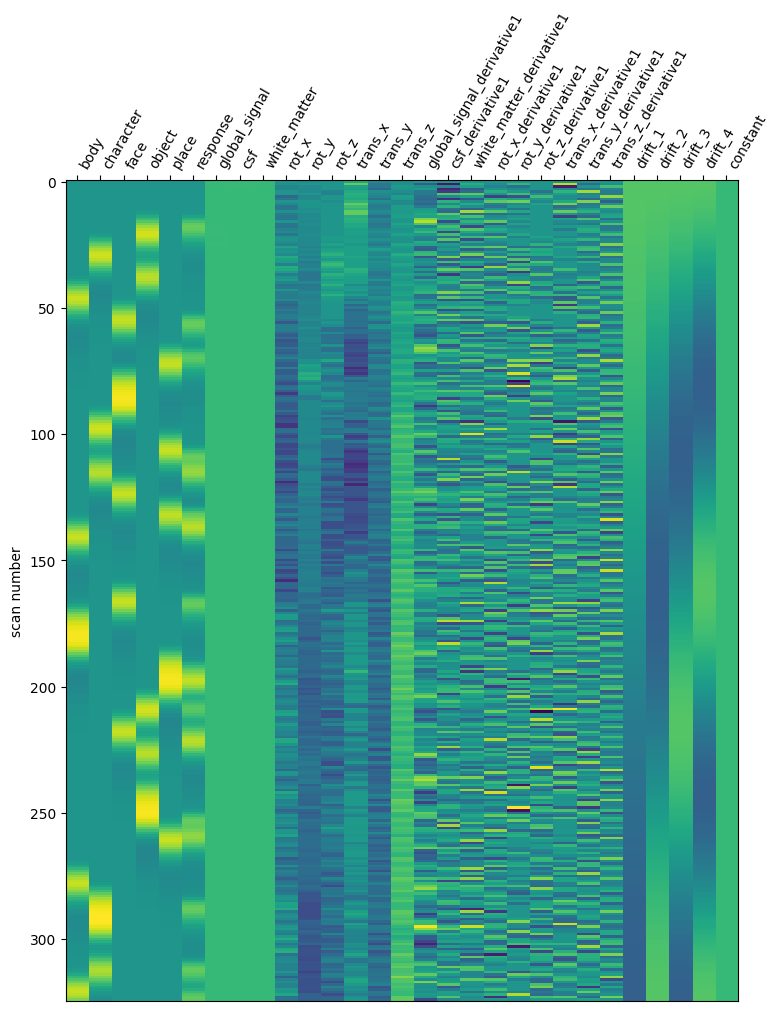

In [ ]:
# Visualise the design matrix
plotting.plot_design_matrix(design_matrix)
plotting.show()

In the design matrix above, the first five columns correspond to the experimental conditions (body, character, face, object, place).  
The remaining columns are the confound regressors and drift terms that we included to account for noise.

We can also examine the **predicted BOLD response** for a single condition.  
The plot below shows the expected response for the **face** condition — the peaks correspond to the blocks in which face stimuli were presented.

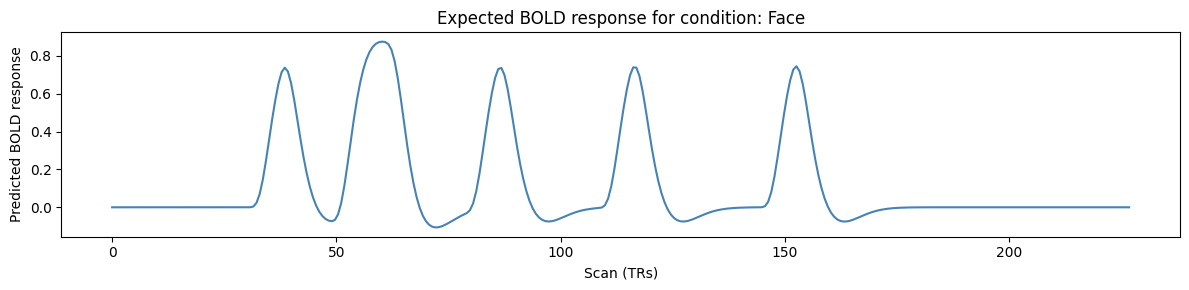

In [ ]:
plt.figure(figsize=(12, 3))
plt.plot(design_matrix['face'], color='steelblue', linewidth=1.5)
plt.xlabel('Scan (TRs)')
plt.ylabel('Predicted BOLD response')
plt.title('Expected BOLD response for condition: Face')
plt.tight_layout()
plt.show()

## Step 5: Defining contrasts

Once the model has been fitted, we need to define **contrasts** to test specific hypotheses about brain activity.  
A contrast is a **linear combination of the model parameters** (the columns of the design matrix).

For example, the contrast **Face > Body** asks: *which voxels respond more strongly during face blocks than during body blocks?*  
This is expressed as a vector that assigns a weight of **+1** to the face column and **−1** to the body column, with all other columns set to 0.

The column order in our design matrix is: `body, character, face, object, place, [confounds...]`.  
So the first five values in the contrast vector correspond to these five conditions.

We pad the rest of the vector with zeros so that the confounds are not controlled for when we compare the conditions.

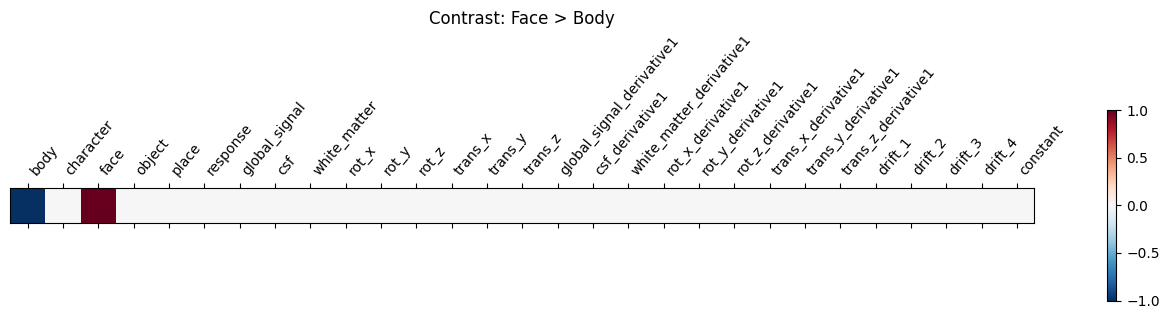

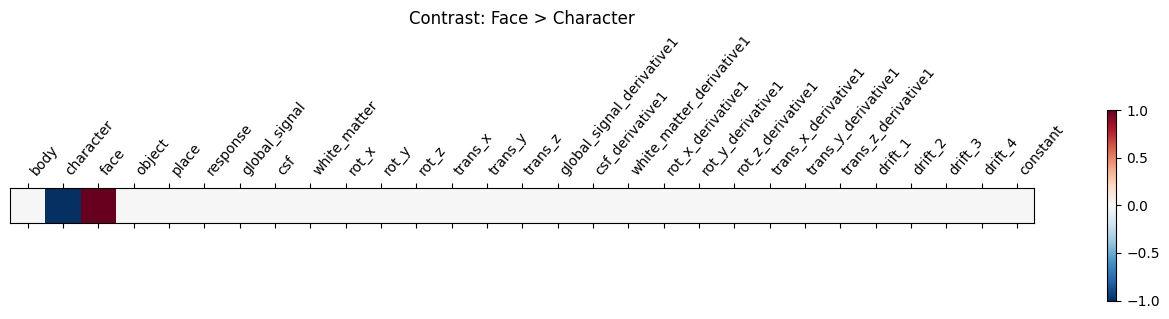

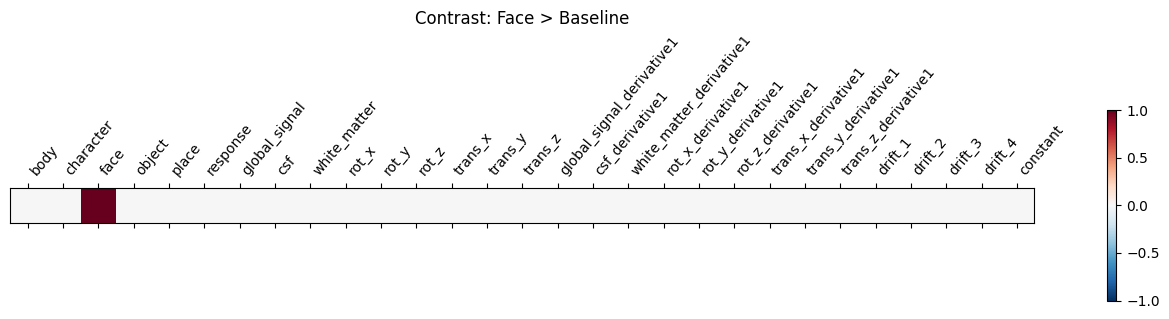

In [ ]:
# Define contrasts as vectors over the condition columns
# Column order: body, character, face, object, place
contrasts = {
    "Face > Body":      np.array([-1.,  0.,  1.,  0.,  0.]),
    "Face > Character": np.array([ 0., -1.,  1.,  0.,  0.]),
    "Face > Baseline":  np.array([ 0.,  0.,  1.,  0.,  0.]),
}

# Pad each contrast vector to match the total number of columns in the design matrix
n_cols = design_matrix.shape[1]
for name, vector in contrasts.items():
    contrasts[name] = np.pad(vector, (0, n_cols - len(vector)), mode="constant")

# Visualise the contrast matrices
for contrast_name, contrast_vector in contrasts.items():
    plotting.plot_contrast_matrix(contrast_vector, design_matrix=design_matrix)
    plt.title(f"Contrast: {contrast_name}")
    plt.show()

Notice how each contrast assigns positive and negative weights to specific conditions.

A few things to keep in mind when constructing contrasts:

- A contrast like **Face > Body** (`[-1, 0, 1, 0, 0]`) tests a **directed difference** between two conditions.  
- A contrast like **Face > Baseline** (`[0, 0, 1, 0, 0]`) tests whether the face condition differs from the implicit baseline (rest periods).  
- When comparing one condition against the **average of multiple conditions**, the negative weights should sum to −1. For example, **Face > (Object + Place)** would be `[0, 0, 1, -0.5, -0.5]`.  
- When comparing one condition against **all other conditions**, each negative weight equals −1 divided by the number of comparison conditions. For example, **Face > (Body + Character + Object + Place)** would be `[-0.25, -0.25, 1, -0.25, -0.25]`.

## Step 6: Computing contrasts and visualising results

With the contrasts defined, we can now compute a **statistical map** for each one.  
Nilearn produces a **z-score map**, where each voxel receives a z-value reflecting how strongly it supports the contrast.

We then visualise these maps using a **glass brain plot** — a transparent brain outline that shows activations across the entire brain in a single view.

In [ ]:
# Compute z-maps for each contrast
z_maps = {}

for name, vector in contrasts.items():
    z_map = fmri_glm_fit.compute_contrast(vector, output_type="z_score")
    z_maps[name] = z_map
    print(f"Computed z-map for contrast: {name}")

Computed z-map for contrast: Face > Body
Computed z-map for contrast: Face > Character
Computed z-map for contrast: Face > Baseline


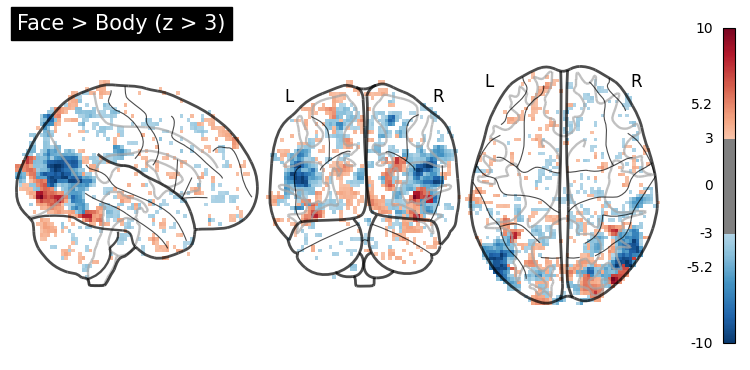

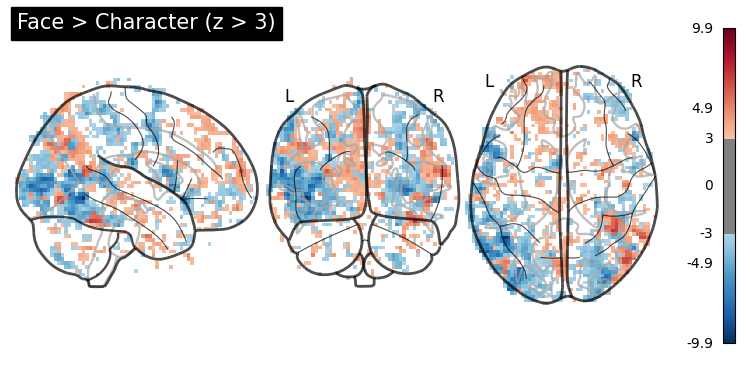

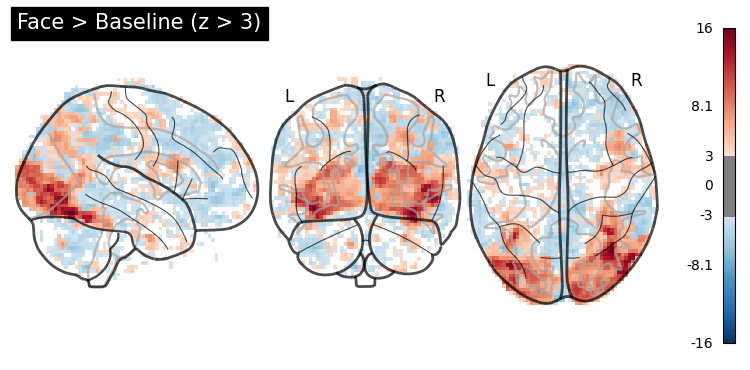

In [ ]:
# Visualise each z-map on a glass brain
for contrast_name, z_map in z_maps.items():
    plotting.plot_glass_brain(
        z_map,
        threshold=3,
        plot_abs=False,
        title=f"{contrast_name} (z > 3)"
    )
    plotting.show()

Take a moment to examine the results:

- The **Face > Body** contrast highlights regions that respond more to faces than to bodies. The clusters in the ventral temporal cortex likely correspond to the **fusiform face area (FFA)** and the **occipital face area (OFA)** — regions that are known to be selectively responsive to faces.  
- The **Face > Character** contrast shows a broadly similar pattern, since both contrasts isolate face-selective processing.  
- The **Face > Baseline** contrast is more widespread, because it picks up any region that is more active during face blocks than during rest — including general visual processing regions that respond to any visual stimulus.

Note that we used an **uncorrected threshold of z > 3** for this demonstration. In a formal analysis, you would apply a **multiple comparisons correction** (such as FDR or cluster-based thresholding) to control the rate of false positives.

## Step 7: F-contrasts for broader hypotheses

Sometimes, rather than testing a single directed comparison, we want to ask a broader question: *does this region differentiate faces from other categories at all?*

For this, we can use an **F-test**, which evaluates whether a **set of contrasts** jointly explains significant variance.  
Unlike a t-test, an F-test does not tell us the direction of the effect — only that a reliable difference exists.

We create an F-contrast by stacking multiple t-contrast vectors into a matrix.

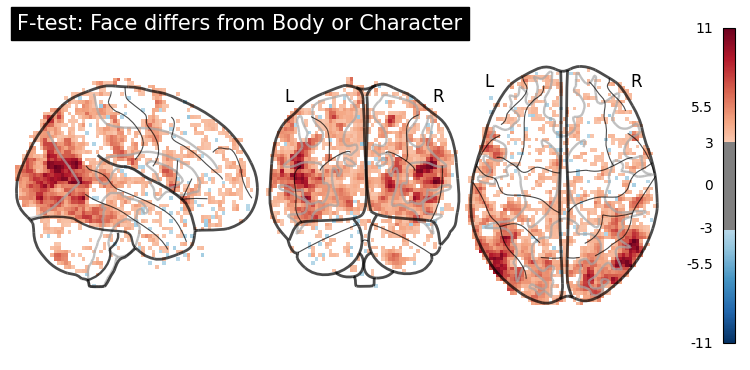

In [ ]:
# Stack two t-contrasts into an F-contrast
effects_of_interest = np.vstack([
    contrasts["Face > Body"],
    contrasts["Face > Character"]
])

# Compute the F-test
face_f_zmap = fmri_glm_fit.compute_contrast(
    effects_of_interest,
    output_type="z_score"
)

# Visualise
plotting.plot_glass_brain(
    face_f_zmap,
    threshold=3,
    plot_abs=False,
    title="F-test: Face differs from Body or Character"
)
plotting.show()

The F-test reveals regions where faces elicit a reliably different response compared to either bodies or characters.  
The resulting clusters are consistent with the core face-processing network described in the literature.

---

**Summary**

You have now seen the full pipeline for a first-level fMRI analysis:

1. **Load** the events file (what happened and when) and the confounds (nuisance regressors)  
2. **Define** the model settings (TR, HRF, smoothing, noise model)  
3. **Fit** the model to the preprocessed BOLD data  
4. **Inspect** the design matrix to verify the model structure  
5. **Define contrasts** to test specific hypotheses  
6. **Compute** statistical maps and visualise the results

In the exercises below, you will apply these steps yourself.

---
# Exercises

### Exercise 1: Building a design matrix for a different experiment (3 points)

Imagine we are working with data from a different experiment.

In this experiment, participants listened to sequences of tones and pressed a button whenever they detected a **target tone** that differed from the preceding **standard tones**.

This is known as an **auditory oddball paradigm** — a classic design in cognitive neuroscience.

The events file for this experiment has already been downloaded (`sub-01_task-auditoryoddball_events.tsv`).

**Your tasks:**

1. Load the events file and select the three required columns (`onset`, `duration`, `trial_type`).  
2. Print the unique trial types in this experiment.
3. Create a design matrix using `make_first_level_design_matrix()` with the same settings as in the demonstration (TR = 0.7, HRF model = `'spm'`, high-pass = 0.01).
4. Plot the resulting design matrix.

**Hints:**
- For the `frame_times` parameter, you need to provide the time (in seconds) of each TR. You can generate this using `np.arange(n_timepoints) * t_r`. Use 325 time points (the same as our flocBLOCKED data).  
- The function `make_first_level_design_matrix()` creates a design matrix *without* fitting a model — this is useful for inspecting the design on its own.

In [ ]:
# Exercise 1: Build a design matrix for the auditory oddball experiment

# 1. Load the events file
audio_events = # YOUR CODE HERE

# 2. Print the unique trial types
print('Trial types:', # YOUR CODE HERE)

# 3. Create the design matrix
#    Hint: frame_times should be an array of TR onset times in seconds
frame_times = # YOUR CODE HERE

audio_design_matrix = make_first_level_design_matrix(
    frame_times=frame_times,
    events=audio_events,
    hrf_model='spm',
    high_pass=0.01,
)

# 4. Plot the design matrix
plot_design_matrix(audio_design_matrix)
plt.title('Design matrix: Auditory Oddball Experiment')
plotting.show()

SyntaxError: invalid syntax (2042701467.py, line 4)

<div class="alert alert-success">
<b>Check your answer:</b> The design matrix should contain <b>3 columns for the experimental conditions</b> (corresponding to the three trial types in the auditory oddball experiment), plus several <b>drift columns</b> and one <b>constant</b> column.
</div>

## Exercise 2: Defining contrast vectors (4 points)

Return to the **flocBLOCKED** data from the demonstration.

Recall that the first five columns of the design matrix correspond to the conditions in this order: **body, character, face, object, place**.

For each contrast below, fill in the correct weights for these five conditions.  
You can ignore the confound columns — zeros will be added automatically by the padding code.

**Define the following contrasts:**

1. **Face > Object** — Does the face condition produce more activation than the object condition?  
2. **Place > Face** — Does the place condition produce more activation than the face condition?  
3. **Face > (Object + Place)** — Does the face condition produce more activation than the average of objects and places?  
4. **Face > (Body + Object + Place)** — Does the face condition produce more activation than the average of bodies, objects, and places?

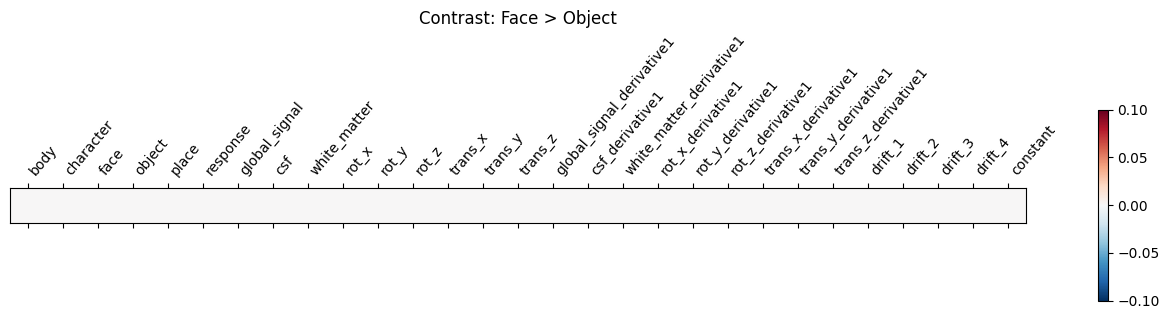

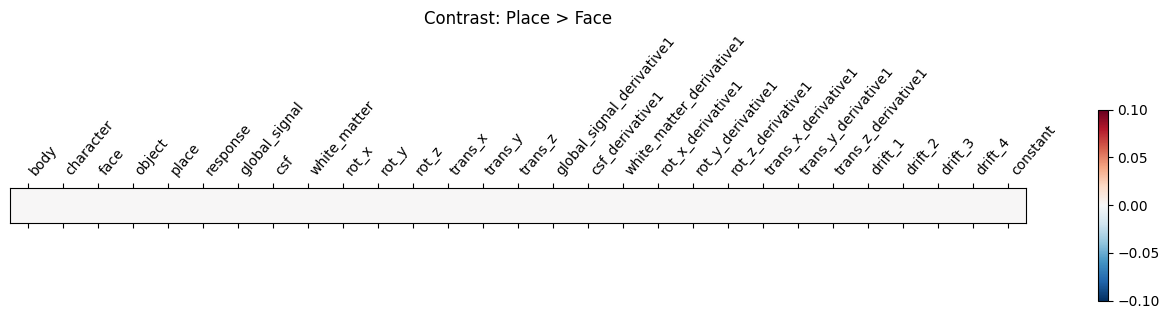

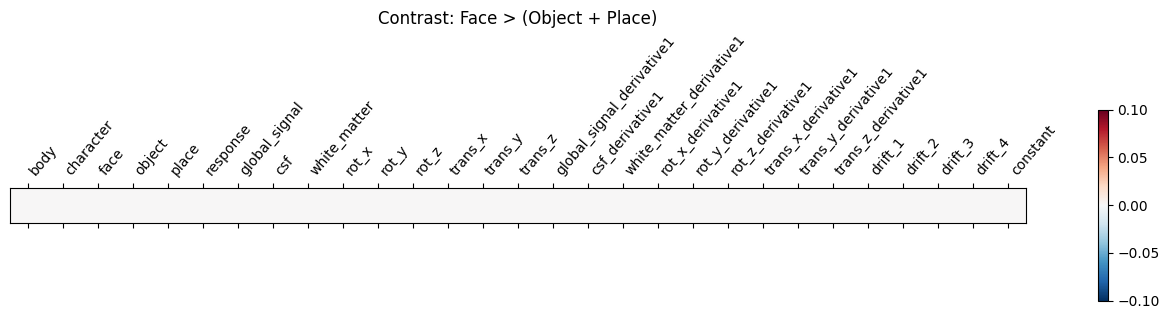

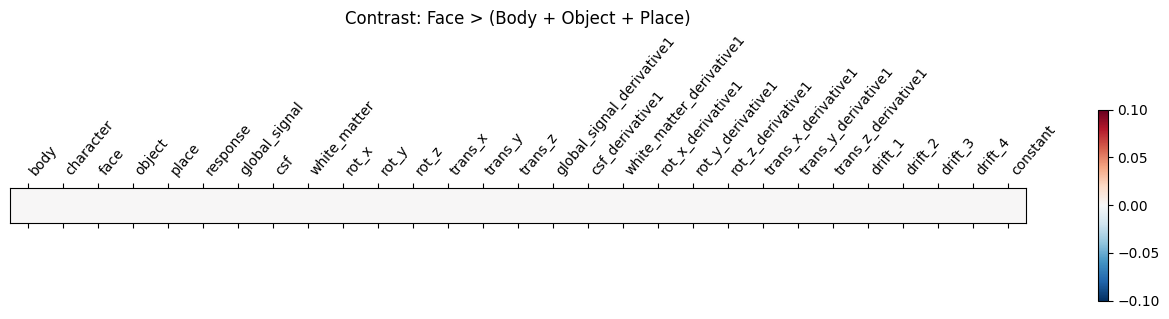

In [ ]:
# Exercise 2: Define contrast vectors
# Column order: body, character, face, object, place

new_contrasts = {
    "Face > Object":                  np.array([0.,  0.,  0.,  0.,  0.]),  # Replace with correct weights
    "Place > Face":                   np.array([0.,  0.,  0.,  0.,  0.]),  # Replace with correct weights
    "Face > (Object + Place)":        np.array([0.,  0.,  0.,  0.,  0.]),  # Replace with correct weights
    "Face > (Body + Object + Place)": np.array([0.,  0.,  0.,  0.,  0.]),  # Replace with correct weights
}

# Pad each contrast to match the full design matrix
n_cols = design_matrix.shape[1]
for name, vector in new_contrasts.items():
    new_contrasts[name] = np.pad(vector, (0, n_cols - len(vector)), mode="constant")

# Visualise each contrast to verify
for contrast_name, contrast_vector in new_contrasts.items():
    plotting.plot_contrast_matrix(contrast_vector, design_matrix=design_matrix)
    plt.title(f"Contrast: {contrast_name}")
    plt.show()

In [ ]:
# Automated checks — run this cell to verify your answers

checks_passed = 0

if np.all(new_contrasts["Face > Object"][0:5] == [0., 0., 1., -1., 0.]):
    print("\u2713 Face > Object is correct")
    checks_passed += 1
else:
    print("\u2717 Face > Object \u2014 check the weights for face (+1) and object (-1)")

if np.all(new_contrasts["Place > Face"][0:5] == [0., 0., -1., 0., 1.]):
    print("\u2713 Place > Face is correct")
    checks_passed += 1
else:
    print("\u2717 Place > Face \u2014 check the weights for place (+1) and face (-1)")

if np.all(new_contrasts["Face > (Object + Place)"][0:5] == [0., 0., 1., -0.5, -0.5]):
    print("\u2713 Face > (Object + Place) is correct")
    checks_passed += 1
else:
    print("\u2717 Face > (Object + Place) \u2014 remember that the negative weights should sum to -1")

if np.allclose(new_contrasts["Face > (Body + Object + Place)"][0:5], [-1/3, 0., 1., -1/3, -1/3]):
    print("\u2713 Face > (Body + Object + Place) is correct")
    checks_passed += 1
else:
    print("\u2717 Face > (Body + Object + Place) \u2014 each comparison condition gets -1/3")

print(f"\n{checks_passed}/4 contrasts correct")

✗ Face > Object — check the weights for face (+1) and object (-1)
✗ Place > Face — check the weights for place (+1) and face (-1)
✗ Face > (Object + Place) — remember that the negative weights should sum to -1
✗ Face > (Body + Object + Place) — each comparison condition gets -1/3

0/4 contrasts correct


## Exercise 3: Computing and visualising contrasts (2 points)

Now compute the z-maps for the contrasts you defined in Exercise 2 and visualise them.

**Your tasks:**

1. For each contrast in `new_contrasts`, compute a z-score map using `fmri_glm_fit.compute_contrast()`.  
2. Plot each map using `plotting.plot_glass_brain()` with a threshold of your choice.

**Hint:** Look at how this was done in the demonstration (Step 6). The pattern is the same — loop through the contrasts, compute each z-map, and plot it.

In [ ]:
# Exercise 3: Compute and visualise your contrasts

# YOUR CODE HERE


## Exercise 4: Interpreting the results (3 points)

Answer the following questions based on what you have observed in this notebook. Write your answers in the markdown cell below.

1. Look at the z-maps for **Face > Object** and **Face > (Body + Object + Place)**. How do the activation patterns differ, and why might this be the case?

2. Why do we include confound regressors (such as motion parameters and the global signal) in the model? What could happen to our results if we left them out?

3. In the demonstration, we observed that the **Face > Baseline** contrast produced more widespread activation than **Face > Body**. Explain why this is expected.

*Write your answers here:*

**Q1:**  


**Q2:**  


**Q3:**  


---
## Bonus Exercise: The Effect of Motion Confounds on the GLM

In the demonstration (Step 2 and Step 3), we included motion parameters and other nuisance regressors in the model to account for noise introduced by head movement and physiological fluctuations. This exercise asks you to investigate what actually changes when you leave those confounds out.

**Your tasks:**

1. Re-fit the `FirstLevelModel` to the same flocBLOCKED data, but this time **omit the confounds** by passing `confounds=None`.  
   Store the result in a new variable called `fmri_glm_no_confounds`.

2. Compute the **Face > Body** contrast from both models (with and without confounds). Use the same contrast vector as in the demonstration. Store the z-maps as `z_face_body_confounds` and `z_face_body_no_confounds`.

3. Plot both z-maps side by side using `plotting.plot_glass_brain()` with a threshold of 3. Add a descriptive title to each plot so the two models are clearly labelled.

4. **Reflect** (write your answer in the markdown cell below): Do the two maps look different? Are there regions that appear in the no-confounds map but not in the confounds map, or vice versa? What does this tell you about the importance of including motion regressors?

*Hint: To re-fit the model, call `fmri_glm.fit(...)` again with the same BOLD file and events, but set `confounds=None`. The model settings (TR, HRF, smoothing, etc.) are already stored in `fmri_glm` and do not need to be redefined.*


In [ ]:
# Bonus Exercise: Motion confounds

# --- Task 1: Re-fit the model without confounds ---
fmri_glm_no_confounds = fmri_glm.fit(
    'sub-03_ses-1_task-flocBLOCKED_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz',
    events=events,
    confounds=None
)

# --- Task 2: Compute Face > Body from both models ---
# Use a string expression rather than a pre-padded vector — this works regardless
# of how many columns each model's design matrix has.
z_face_body_confounds    = fmri_glm_fit.compute_contrast("face - body", output_type="z_score")
z_face_body_no_confounds = fmri_glm_no_confounds.compute_contrast("face - body", output_type="z_score")

# --- Task 3: Plot both z-maps side by side ---
plotting.plot_glass_brain(
    z_face_body_confounds,
    threshold=3,
    plot_abs=False,
    title="Face > Body — with confounds (z > 3)"
)
plotting.show()

plotting.plot_glass_brain(
    z_face_body_no_confounds,
    threshold=3,
    plot_abs=False,
    title="Face > Body — without confounds (z > 3)"
)
plotting.show()

# --- Task 4: Write your reflection in the markdown cell below ---


*Write your reflection here (Task 4):*

**Do the two maps differ? If so, how?**  


**What does this tell you about the role of confound regressors?**  


---
**Well done!**

In this notebook, you learned how to:
- Build a **design matrix** from event files and confound regressors  
- Fit a **first-level GLM** to preprocessed fMRI data using Nilearn  
- Define and interpret **contrast vectors** to test hypotheses about brain activity  
- Compute and visualise **statistical maps** from first-level contrasts  

These skills form the foundation for multivariate predictions that we cover in the rest of the course.